# Causal Impacts of NAO on Precipitation
**Granger-PCA analysis of NAO → Precipitation teleconnections (Europe & India)**

This notebook is a self-contained, publication-ready pipeline:
1. Imports
2. Configuration (parameters for Europe and India experiments)
3. Data loading, cleaning and preprocessing
4. Experiments: GPCA fitting + baseline comparisons
5. Results: Granger causality tests, EVR summary table, spatial weight maps
6. Final composite figure (A–D) ready for publication

## 1 — Imports

In [1]:
# Standard library
import os
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append("../")

# Data
import numpy as np
import pandas as pd
import xarray as xr
import regionmask
from scipy.signal import detrend
from scipy.stats import pearsonr

# Visualisation
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import matplotlib.ticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ML / stats
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from scipy.stats import t as student_t
from tqdm import tqdm

# Local package — GPCA + teleconnection baselines
from models.granger_pca import GrangerPCA
from models.teleconnection_models import (
    RegressionAnalysis, CompositeAnalysis,
    CanonicalCorrelationAnalysis, SpatialAveraging, PrincipalComponents,
)
from src.granger_causality_test import test_granger_causality, test_granger_causality_mbb
from src.xarray_numpy import xr2np, np2D_to_np3D
from src.plot_weights import plot_weight_maps
from src.utils_v2 import get_weights, explained_variance_ratio_fast

np.random.seed(1234)

## 2 — Configuration
All experiment parameters are centralised here — one sub-dict per region.

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR   = "../data"
NAO_FILE   = "/home/homer/Documents/Research/Data/Climate_Oscillation/norm.daily.nao.cdas.z500.19500101_current.csv"
PRECIP_FILES = {
    "Europe": "/home/homer/Documents/Research/Data/ERA5/pr/era5_total_pr_daily_europe_72N_34N_25W_45E.nc",
    "India":  "/home/homer/Documents/Research/Data/ERA5/pr/era5_total_pr_daily_india.nc",
}

# ── Per-region experiment parameters ─────────────────────────────────────────
REGION_CONFIGS = {
    "Europe": {
        "lag":            3,                       # optimal lag (months) for NAO → precip
        "gc_test_lags":   np.arange(1, 10),         # lags evaluated in GC test plot
        "coarsen_factor": 2,                       # spatial coarsening factor
        "sign_flip":      True,                    # multiply PCA weights by -1 to align spatial patterns
        "fig_label":      "(A)",                   # panel label in final figure
        "gc_label":       "(C)",                   # GC panel label in final figure
    },
    "India": {
        "lag":            8,                      # optimal lag (months) for NAO → precip
        "gc_test_lags":   np.arange(5, 15),         # lags evaluated in GC test plot
        "coarsen_factor": 2,                       # spatial coarsening factor
        "sign_flip":      True,                    # multiply PCA weights by -1 to align spatial patterns
        "fig_label":      "(B)",                   # panel label in final figure
        "gc_label":       "(D)",                   # GC panel label in final figure
    },
}

# ── Shared preprocessing ──────────────────────────────────────────────────────
TRAIN_RATIO      = 0.80               # fraction for training
N_PCA_COMPONENTS = 100                 # PCA pre-reduction dimensionality
DETRENDING       = True               # detrend NAO and precipitation
LOG_TRANSFORM    = True               # log-transform precipitation anomalies

# ── GPCA hyperparameters ──────────────────────────────────────────────────────
ALPHA_RIDGE    = np.logspace(-5, 20, 100)
ALPHA_STAB     = 1e-7                 # numerical stabilisation parameter
N_BLOCKS_CV    = 5                    # blocks for block-CV residual computation

# ── Results ───────────────────────────────────────────────────────────────────
CORR_SIG_ALPHA    = 0.05              # pixel-wise correlation significance level
CORR_CORRECTION   = True             # apply Bonferroni multiple-testing correction
CORR_BOOTSTRAP    = False            # use bootstrap (True) or analytical t-test (False)
CORR_N_BOOTSTRAP  = 1000             # bootstrap iterations (only used if CORR_BOOTSTRAP=True)

REGIONS = list(REGION_CONFIGS.keys())  # ["Europe", "India"]

## 3 — Data Loading, Cleaning & Preprocessing

In [3]:
def load_and_preprocess(region: str, cfg: dict):
    """
    Load precipitation and NAO data for a given region, compute anomalies,
    apply optional detrending and log-transform, and return ready-to-use arrays.

    Returns
    -------
    anomalies   : np.ndarray  (n_times, n_pixels)
    oscillation : np.ndarray  (n_times,)
    mask        : xr.DataArray  land mask
    lon         : np.ndarray  longitude axis
    lat         : np.ndarray  latitude axis
    """
    # ── Load precipitation ─────────────────────────────────────────────────
    coarsen = cfg["coarsen_factor"]
    precip_ds = (
        xr.open_dataset(PRECIP_FILES[region])
        .coarsen(latitude=coarsen, longitude=coarsen, boundary="trim")
        .mean()
    )

    if region == "India":
        # Sort time and trim last 17 days to align with NAO record
        precip_ds = precip_ds.sortby("valid_time").isel(valid_time=slice(None, -17))

    # Seasonal anomalies
    seasonalities    = precip_ds.groupby("valid_time.month").mean("valid_time")
    precip_anomalies = precip_ds.groupby("valid_time.month") - seasonalities

    # Land mask
    land = regionmask.defined_regions.natural_earth_v5_0_0.land_50
    mask = land.mask(precip_anomalies.tp,
                     lon_name="longitude", lat_name="latitude")

    anomalies   = xr2np(precip_anomalies, mask, var="tp")  # (n_times, n_pixels)
    valid_dates = pd.to_datetime(precip_anomalies.valid_time.values)

    # ── Load NAO index ─────────────────────────────────────────────────────
    df_nao = pd.read_csv(NAO_FILE)
    df_nao["date"] = pd.to_datetime(df_nao[["year", "month", "day"]])
    df_nao.set_index("date", inplace=True)
    oscillation = (
        df_nao.loc[df_nao.index.intersection(valid_dates), "nao_index_cdas"]
        .fillna(0)
        .to_numpy()
    )

    # ── Optional transformations ───────────────────────────────────────────
    if DETRENDING:
        anomalies   = detrend(anomalies,   axis=0, type="linear")
        oscillation = detrend(oscillation, axis=0, type="linear")

    if LOG_TRANSFORM:
        anomalies = anomalies - np.min(anomalies) + 1e-8
        anomalies = np.log(anomalies)

    lon = precip_anomalies["tp"].longitude.values
    lat = precip_anomalies["tp"].latitude.values

    print(f"[{region}]  anomalies: {anomalies.shape}  |  "
          f"oscillation: {oscillation.shape}  |  "
          f"dates: {valid_dates[0].date()} → {valid_dates[-1].date()}")

    return anomalies, oscillation, mask, lon, lat


# Load both regions
data = {}
for region in REGIONS:
    data[region] = load_and_preprocess(region, REGION_CONFIGS[region])

[Europe]  anomalies: (16437, 4983)  |  oscillation: (16437,)  |  dates: 1980-01-01 → 2024-12-31
[India]  anomalies: (19630, 2422)  |  oscillation: (19630,)  |  dates: 1972-01-01 → 2025-09-28


In [4]:
def split_and_reduce(anomalies, oscillation):
    """
    Train/test chronological split, then PCA pre-reduction.

    Returns a dict with train/test splits and PCA-reduced versions.
    """
    n          = len(anomalies)
    train_size = int(n * TRAIN_RATIO)

    anom_train = anomalies[:train_size]
    anom_test  = anomalies[train_size:]
    osc_train  = oscillation[:train_size]
    osc_test   = oscillation[train_size:]

    pca = PCA(n_components=N_PCA_COMPONENTS)
    pca.fit(anom_train)

    return {
        "anom_train":     anom_train,
        "anom_test":      anom_test,
        "anom_all":       anomalies,
        "osc_train":      osc_train,
        "osc_test":       osc_test,
        "osc_all":        oscillation,
        "pca_train":      pca.transform(anom_train),
        "pca_test":       pca.transform(anom_test),
        "pca_all":        pca.transform(anomalies),
        "pca_model":      pca,
        "train_size":     train_size,
    }


splits = {}
for region in REGIONS:
    anomalies, oscillation, *_ = data[region]
    splits[region] = split_and_reduce(anomalies, oscillation)
    s = splits[region]
    print(f"[{region}]  train: {s['train_size']}  |  "
          f"test: {len(s['anom_test'])}  |  "
          f"variance retained: "
          f"{s['pca_model'].explained_variance_ratio_.sum()*100:.1f}%")

[Europe]  train: 13149  |  test: 3288  |  variance retained: 68.3%
[India]  train: 15704  |  test: 3926  |  variance retained: 72.3%


## 4 — Experiments

### 4.2 GPCA fitting and baseline comparisons

In [5]:
results = {}   # will hold everything needed for plotting

for region in REGIONS:
    print(f"\n{'='*60}")
    print(f"  Region: {region}  |  lag = {REGION_CONFIGS[region]['lag']}")
    print(f"{'='*60}")

    cfg = REGION_CONFIGS[region]
    s   = splits[region]
    lag = cfg["lag"]

    # ── Fit GPCA ──────────────────────────────────────────────────────────
    gpca = GrangerPCA(
        maxlag=lag,
        model_res=RidgeCV(alphas=ALPHA_RIDGE),
        model_full=RidgeCV(alphas=ALPHA_RIDGE),
        alpha=ALPHA_STAB,
        residuals_computation="block_cv",
        block_cv_n_blocks=N_BLOCKS_CV,
    )
    gpca.fit(s["osc_train"][:, None], s["pca_train"],
             plot_lag_analysis=False, verbose=True)

    cp_test_gpca = gpca.transform(s["pca_test"])

    # ── Fit baseline methods at the same lag ──────────────────────────────
    ca  = CompositeAnalysis(maxlag=lag)
    ra  = RegressionAnalysis(maxlag=lag)
    cca = CanonicalCorrelationAnalysis(maxlag=lag, n_components=1)
    sa  = SpatialAveraging()
    pc  = PrincipalComponents()

    ca.fit(s["osc_train"][:, None],  s["pca_train"])
    ra.fit(s["osc_train"][:, None],  s["pca_train"])
    cca.fit(s["osc_train"][:, None], s["pca_train"])
    sa.fit(s["osc_train"][:, None],  s["anom_train"])
    pc.fit(s["osc_train"][:, None],  s["anom_train"])

    cp_test_ca  = ca.transform(s["pca_test"], type="PosNeg")
    cp_test_ra  = ra.transform(s["pca_test"])
    cp_test_cca = cca.transform(s["pca_test"])
    cp_test_sa  = sa.transform(s["anom_test"])
    cp_test_pc  = pc.transform(s["anom_test"])

    # ── Spatial correlation weights (full dataset) ────────────────────────
    corr_gpca, sig_gpca = get_weights(s["pca_all"], s["anom_all"], algo=gpca,
                                      alpha=CORR_SIG_ALPHA, correction=CORR_CORRECTION, 
                                      bootstrap=CORR_BOOTSTRAP, n_bootstrap=CORR_N_BOOTSTRAP)
    corr_ca,   sig_ca   = get_weights(s["pca_all"], s["anom_all"], algo=ca,
                                      alpha=CORR_SIG_ALPHA, 
                                      correction=CORR_CORRECTION, bootstrap=CORR_BOOTSTRAP, 
                                      n_bootstrap=CORR_N_BOOTSTRAP)
    corr_ra,   sig_ra   = get_weights(s["pca_all"], s["anom_all"], algo=ra, 
                                      alpha=CORR_SIG_ALPHA, correction=CORR_CORRECTION, 
                                      bootstrap=CORR_BOOTSTRAP, n_bootstrap=CORR_N_BOOTSTRAP)
    corr_cca,  sig_cca  = get_weights(s["pca_all"], s["anom_all"], algo=cca, 
                                      alpha=CORR_SIG_ALPHA, correction=CORR_CORRECTION, 
                                      bootstrap=CORR_BOOTSTRAP, n_bootstrap=CORR_N_BOOTSTRAP)
    corr_sa,   sig_sa   = get_weights(s["anom_all"], s["anom_all"], algo=sa, 
                                      alpha=CORR_SIG_ALPHA, correction=CORR_CORRECTION, 
                                      bootstrap=CORR_BOOTSTRAP, n_bootstrap=CORR_N_BOOTSTRAP)
    corr_pc,   sig_pc   = get_weights(s["anom_all"], s["anom_all"], algo=pc, 
                                      alpha=CORR_SIG_ALPHA, correction=CORR_CORRECTION, 
                                      bootstrap=CORR_BOOTSTRAP, n_bootstrap=CORR_N_BOOTSTRAP)

    # Optional sign flip (see config) to align with published spatial patterns
    if cfg["sign_flip"]:
        corr_gpca = -corr_gpca

    results[region] = {
        "gpca":       gpca,
        "cp_test":    {
            "gpca": cp_test_gpca, "ca": cp_test_ca, "ra": cp_test_ra,
            "cca":  cp_test_cca,  "sa": cp_test_sa, "pc": cp_test_pc,
        },
        "weights":    {
            "gpca": (np.ravel(corr_gpca), sig_gpca),
            "ra":   (np.ravel(corr_ra),   sig_ra),
            "ca":   (np.ravel(corr_ca),   sig_ca),
            "cca":  (np.ravel(corr_cca),  sig_cca),
            "sa":   (np.ravel(corr_sa),   sig_sa),
            "pc":   (np.ravel(corr_pc),   sig_pc),
        },
    }

print("\nAll experiments complete.")


  Region: Europe  |  lag = 3
       eigs
0  0.121390
1  0.020475
2  0.000670

  Region: India  |  lag = 8
       eigs
0  0.002516
1  0.001269
2  0.000747
3  0.000399
4  0.000266
5  0.000072
6  0.000027
7  0.000014

All experiments complete.


## 5 — Showing / Saving Results
### 5.1 Granger causality p-values across lags

In [6]:
gc_results = {}  # store for later use in the final figure

for region in REGIONS:
    cfg  = REGION_CONFIGS[region]
    s    = splits[region]
    res  = results[region]
    lags = cfg["gc_test_lags"]

    cp = res["cp_test"]

    gc_r = {
        "gpca": test_granger_causality(s["osc_test"][:, None], cp["gpca"][:, 0], maxlag=lags),
        "ra":   test_granger_causality(s["osc_test"][:, None], cp["ra"],          maxlag=lags),
        "ca":   test_granger_causality(s["osc_test"][:, None], cp["ca"],          maxlag=lags),
        "cca":  test_granger_causality(s["osc_test"][:, None], cp["cca"],         maxlag=lags),
        "sa":   test_granger_causality(s["osc_test"][:, None], cp["sa"],          maxlag=lags),
        "pc":   test_granger_causality(s["osc_test"][:, None], cp["pc"],          maxlag=lags),
    }
    gc_results[region] = {"lags": lags, **gc_r}

print("Granger causality tests computed for all regions.")

Granger causality tests computed for all regions.


### 5.2 EVR & Granger causality summary table

In [7]:
os.makedirs("../tables", exist_ok=True)

for region in REGIONS:
    cfg  = REGION_CONFIGS[region]
    s    = splits[region]
    res  = results[region]
    gcr  = gc_results[region]
    lag  = cfg["lag"]
    lags = cfg["gc_test_lags"]

    w  = res["weights"]
    method_dict = {
        "GPCA":           (gcr["gpca"], explained_variance_ratio_fast(s["anom_test"], w["gpca"][0])),
        "CCA":            (gcr["cca"],  explained_variance_ratio_fast(s["anom_test"], w["cca"][0])),
        "Composites":     (gcr["ca"],   explained_variance_ratio_fast(s["anom_test"], w["ca"][0])),
        "Regression":     (gcr["ra"],   explained_variance_ratio_fast(s["anom_test"], w["ra"][0])),
        "Spatial Avg":    (gcr["sa"],   explained_variance_ratio_fast(s["anom_test"], w["sa"][0])),
        "PCA":            (gcr["pc"],   explained_variance_ratio_fast(s["anom_test"], w["pc"][0])),
    }

    rows = []
    for method, (gc_df, evr) in method_dict.items():
        row = gc_df[gc_df["lag"] == lag].copy()
        row["EVR"]    = evr
        row["Method"] = method
        rows.append(row)
    table = pd.concat(rows).set_index("Method")[["EVR", "F_statistic", "p_value"]]

    print(f"\n── {region} (lag = {lag}) ──")
    display(table.style.format({"EVR": "{:.4f}", "F_statistic": "{:.3f}", "p_value": "{:.3e}"}))

    latex_str = table.to_latex(
        float_format="%.4f",
        caption=f"Granger causality and EVR comparison — {region} (lag = {lag})",
        label=f"tab:results_{region.lower()}_lag{lag}",
        escape=True,
    )
    path = f"../tables/teleconnection_pvalues_precipitation_{region}_lag{lag}.tex"
    with open(path, "w") as f:
        f.write(latex_str)
    print(f"   LaTeX table saved → {path}")


── Europe (lag = 3) ──


,EVR,F_statistic,p_value
Method,,,
GPCA,0.0300,39.249,6.506e-25
CCA,0.0356,40.401,1.245e-25
Composites,0.0382,25.118,4.609e-16
Regression,0.0387,23.546,4.490e-15
Spatial Avg,0.0275,3.922,8.301e-03
PCA,0.0448,11.086,3.074e-07


   LaTeX table saved → ../tables/teleconnection_pvalues_precipitation_Europe_lag3.tex

── India (lag = 8) ──


,EVR,F_statistic,p_value
Method,,,
GPCA,0.0336,3.675,2.796e-04
CCA,0.0373,3.123,1.602e-03
Composites,0.0458,1.831,6.679e-02
Regression,0.0492,1.797,7.285e-02
Spatial Avg,0.0408,1.792,7.372e-02
PCA,0.0711,0.886,5.274e-01


   LaTeX table saved → ../tables/teleconnection_pvalues_precipitation_India_lag8.tex


### 5.3 Spatial weight maps (all methods, per region)

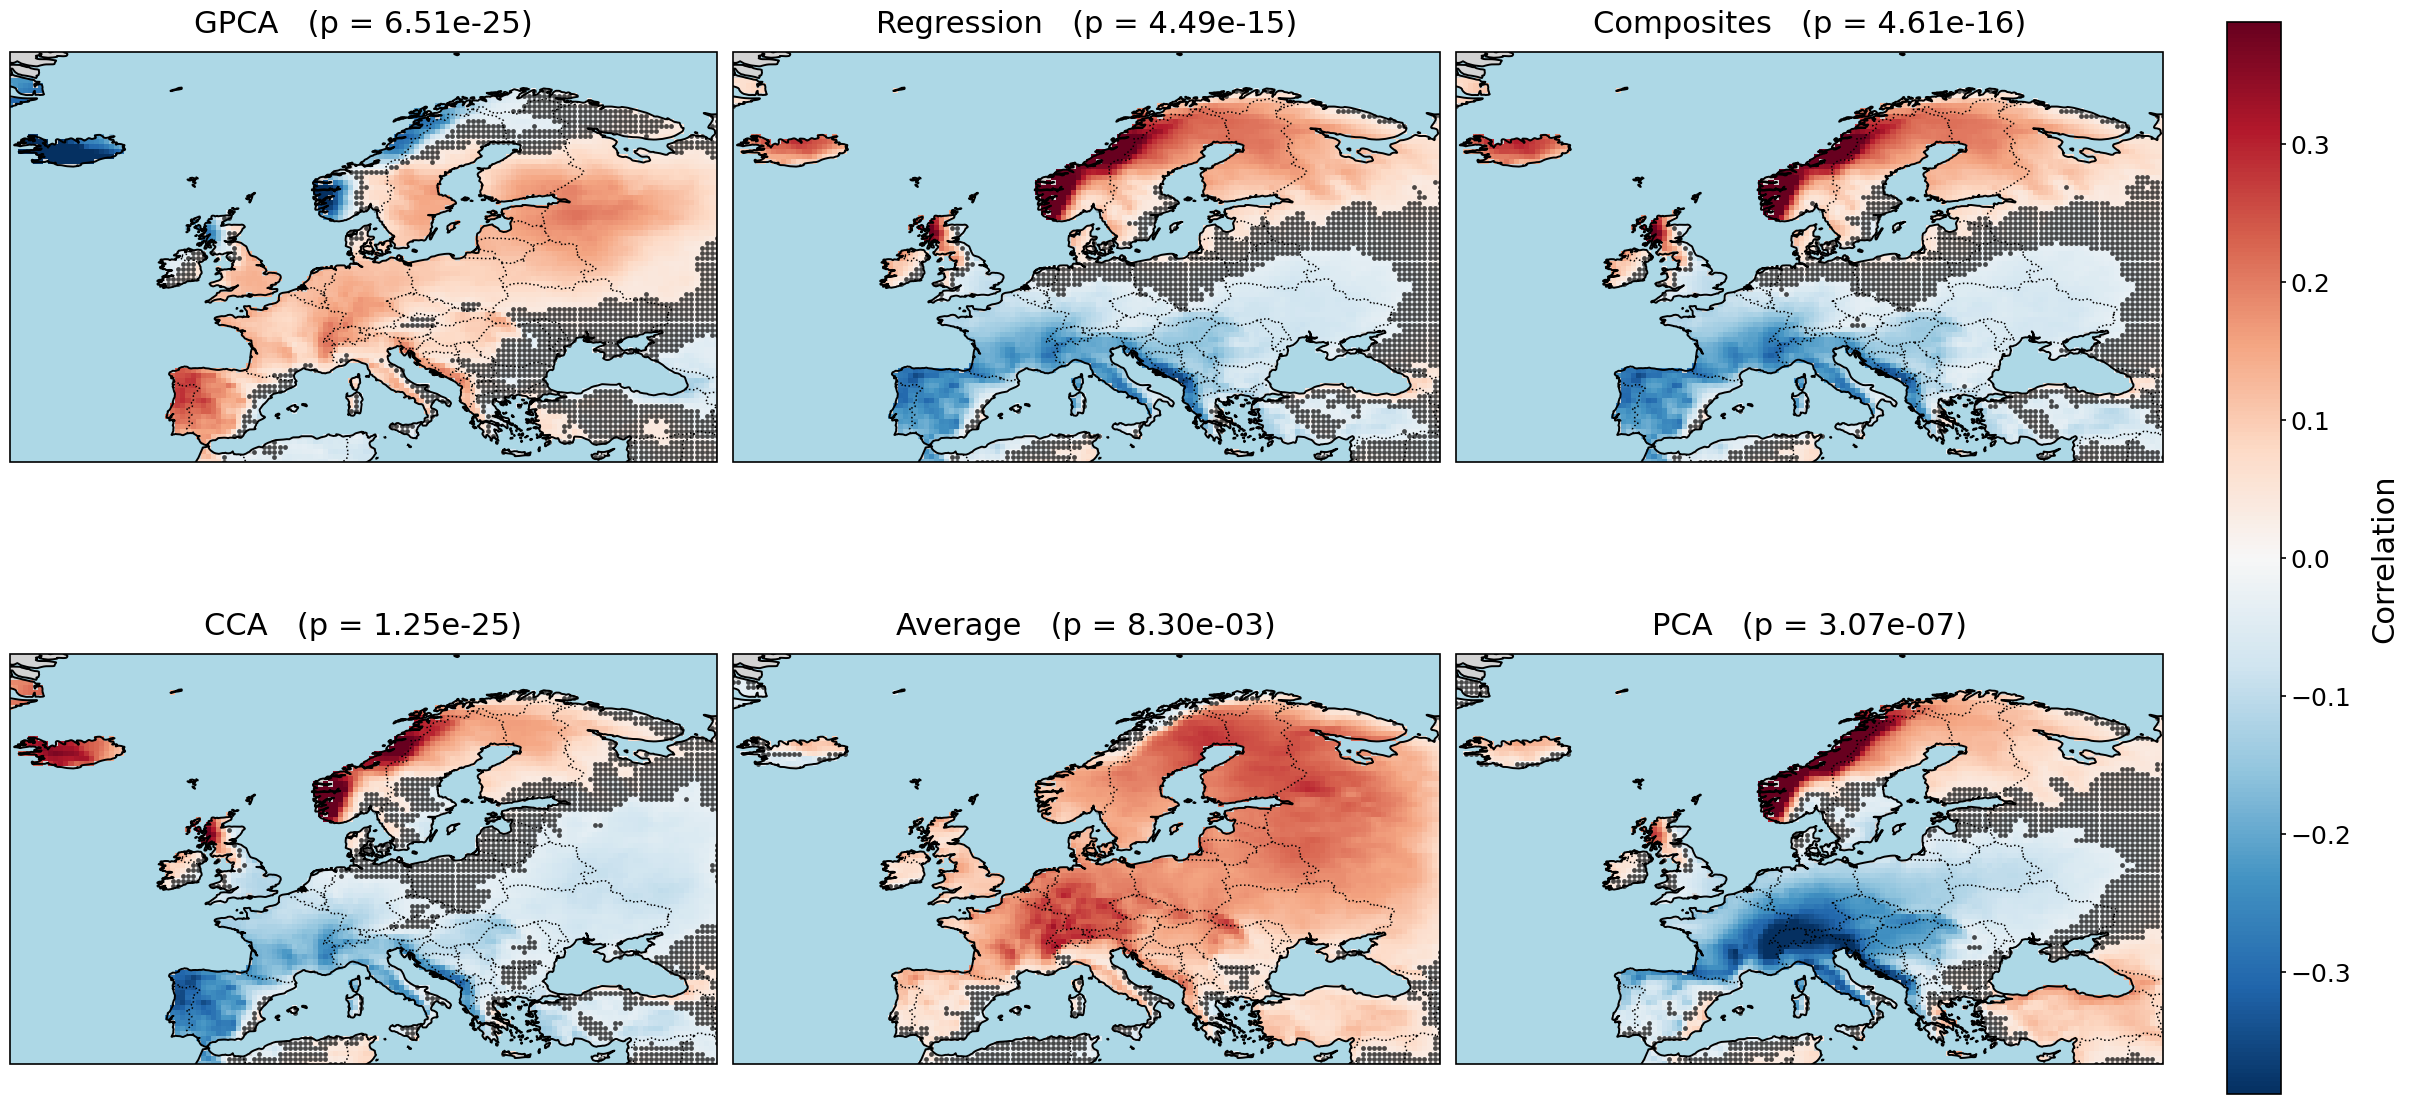

[Europe] weight maps saved → ../figures/teleconnection_weights_precipitation_Europe_lag3.png


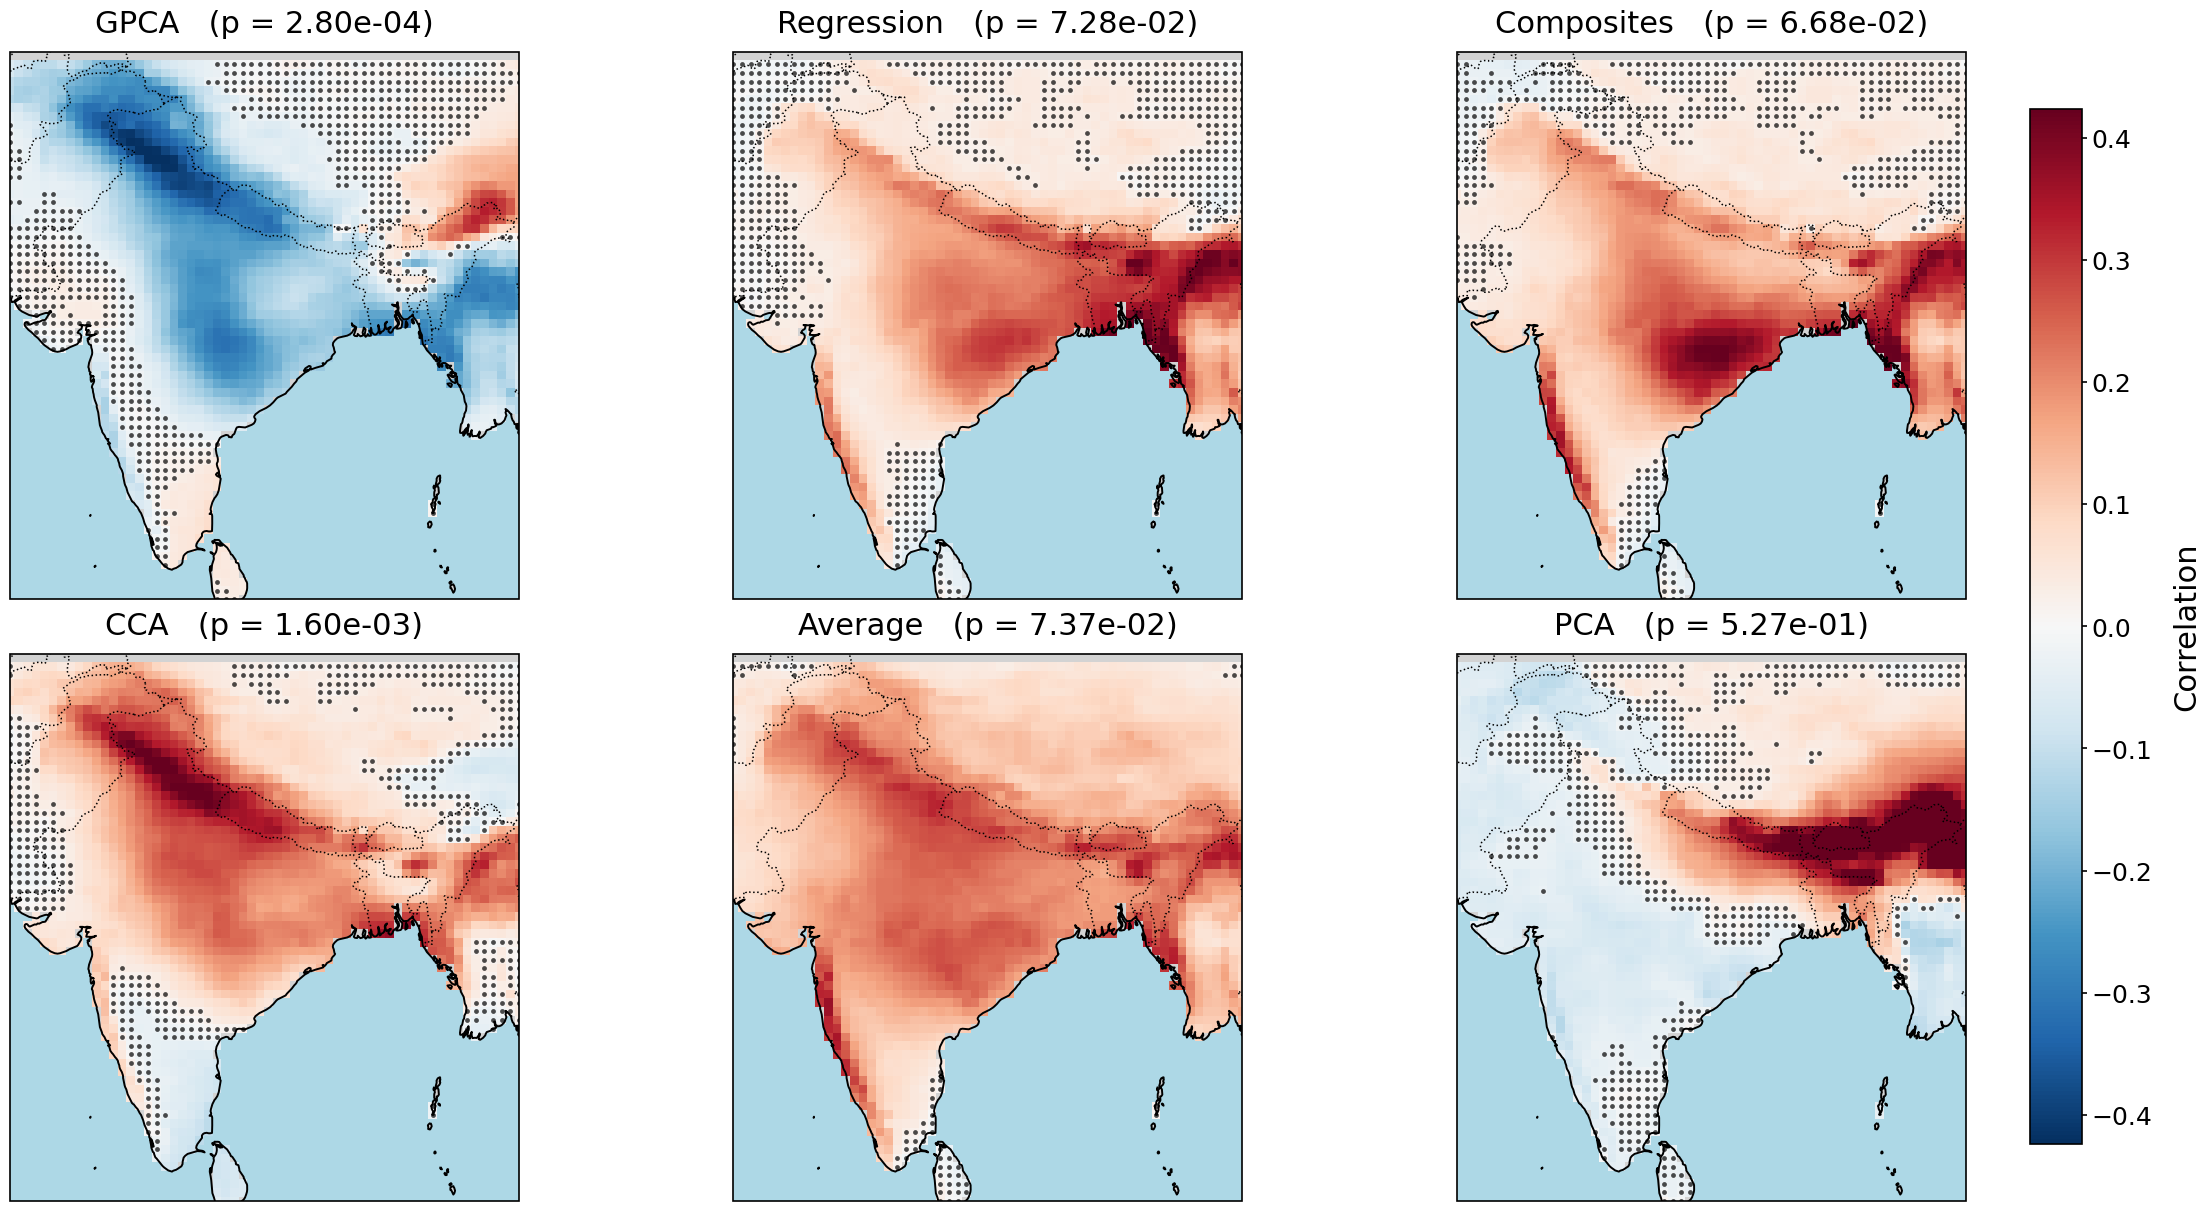

[India] weight maps saved → ../figures/teleconnection_weights_precipitation_India_lag8.png


In [8]:
os.makedirs("../figures", exist_ok=True)

for region in REGIONS:
    cfg  = REGION_CONFIGS[region]
    res  = results[region]
    gcr  = gc_results[region]
    lag  = cfg["lag"]
    lags = cfg["gc_test_lags"]
    _, _, mask, lon, lat = data[region]

    w = res["weights"]

    def to_map(arr):
        return np2D_to_np3D(arr[None, :], mask)[0]

    weight_maps = {
        "GPCA":       {"weights": to_map(w["gpca"][0]), "significances": to_map(w["gpca"][1].astype(float)),
                       "p-value": gcr["gpca"][gcr["gpca"]["lag"] == lag]["p_value"]},
        "Regression": {"weights": to_map(w["ra"][0]),   "significances": to_map(w["ra"][1].astype(float)),
                       "p-value": gcr["ra"][gcr["ra"]["lag"] == lag]["p_value"]},
        "Composites": {"weights": to_map(w["ca"][0]),   "significances": to_map(w["ca"][1].astype(float)),
                       "p-value": gcr["ca"][gcr["ca"]["lag"] == lag]["p_value"]},
        "CCA":        {"weights": to_map(w["cca"][0]),  "significances": to_map(w["cca"][1].astype(float)),
                       "p-value": gcr["cca"][gcr["cca"]["lag"] == lag]["p_value"]},
        "Average":    {"weights": to_map(w["sa"][0]),   "significances": to_map(w["sa"][1].astype(float)),
                       "p-value": gcr["sa"][gcr["sa"]["lag"] == lag]["p_value"]},
        "PCA":        {"weights": to_map(w["pc"][0]),   "significances": to_map(w["pc"][1].astype(float)),
                       "p-value": gcr["pc"][gcr["pc"]["lag"] == lag]["p_value"]},
    }

    path = f"../figures/teleconnection_weights_precipitation_{region}_lag{lag}.png"
    plot_weight_maps(weight_maps, "Precipitation", lon, lat, extent=None, save_path=path)
    print(f"[{region}] weight maps saved → {path}")

## 6 — Final Figure (Publication-Ready)

> **Figure caption:**
> Teleconnection patterns between the North Atlantic Oscillation and precipitation for all
> methods in **(A–C)** Europe (GPCA, Regression, Composites), **(D–F)** Europe (CCA,
> Spatial Average, PCA), **(G–I)** India (GPCA, Regression, Composites) and **(J–L)**
> India (CCA, Spatial Average, PCA). The dotted region represents a non-significant
> correlation (computed using a two-sided *t*-test at level α = 0.05). P-values for the
> GC test of the extracted component across different time lags are shown in **(M)**
> Europe and **(N)** India. The PCA weights have been multiplied by −1 to better align
> with other spatial patterns.

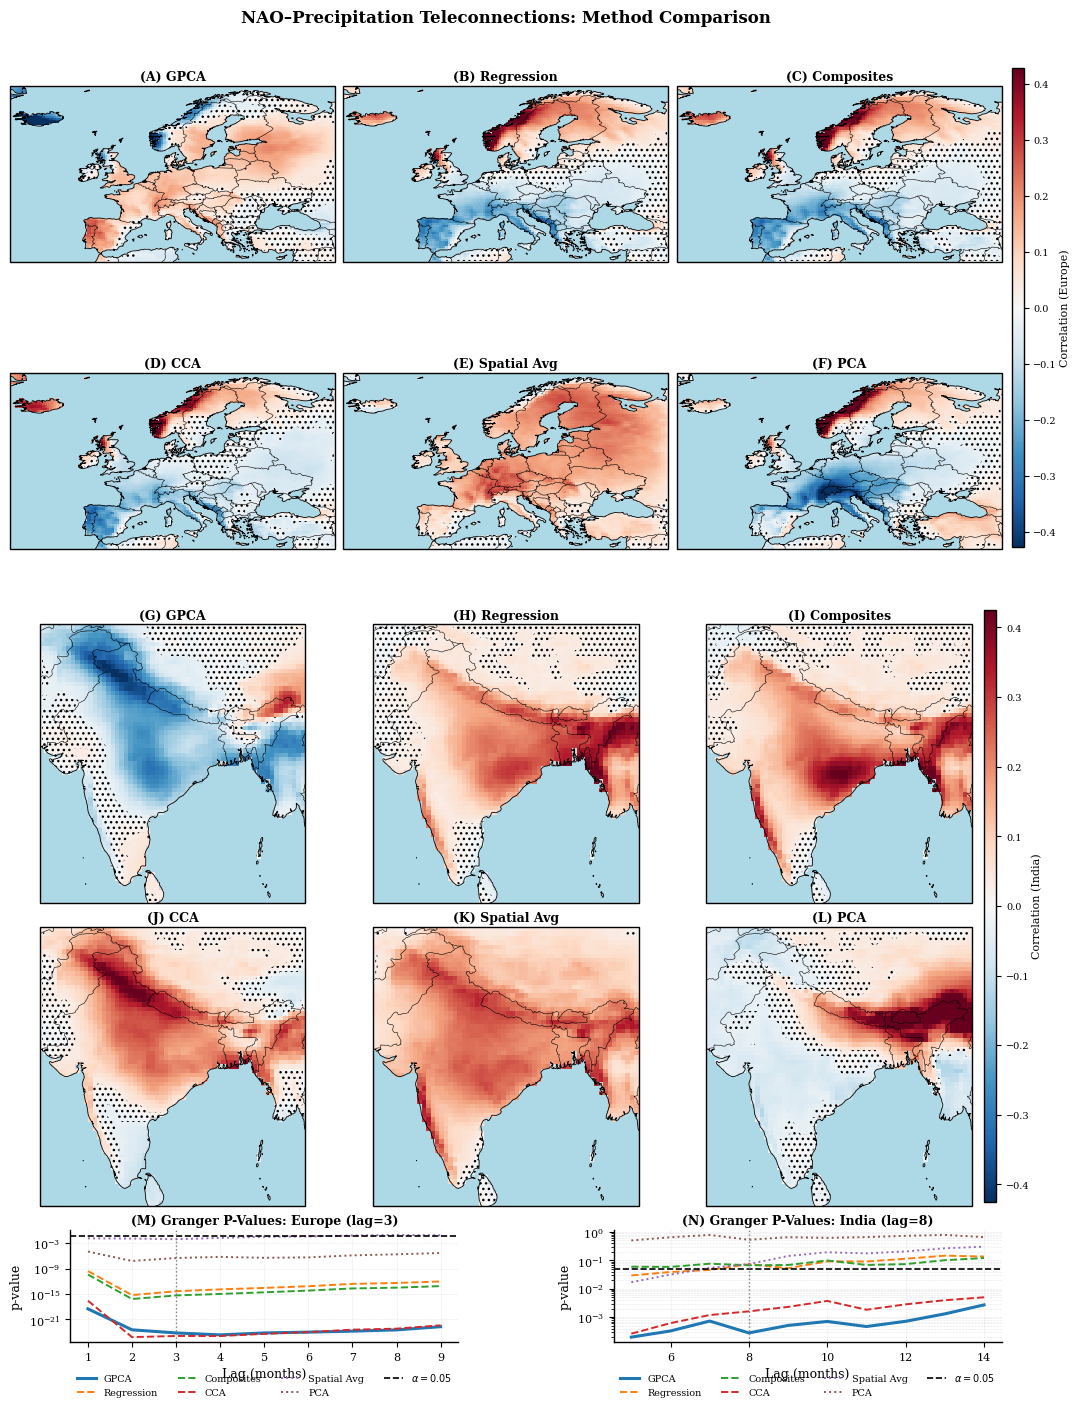

In [9]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os

# ── Publication rc params ───────────────────────────────────────────────────────────
PUB_RC = {
    "font.family":    "serif",
    "font.serif":     ["DejaVu Serif"],
    "font.size":      9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
    "axes.linewidth": 1.0,
    "lines.linewidth": 1.6,
    "pdf.fonttype":   42,
    "ps.fonttype":    42,
}

METHODS = [
    ("gpca", "GPCA",        "tab:blue",   2.2, "-"),
    ("ra",   "Regression",  "tab:orange", 1.4, "--"),
    ("ca",   "Composites",  "tab:green",  1.4, "--"),
    ("cca",  "CCA",         "tab:red",    1.4, "--"),
    ("sa",   "Spatial Avg", "tab:purple", 1.4, ":"),
    ("pc",   "PCA",         "tab:brown",  1.4, ":"),
]

PANEL_LETTERS = list("ABCDEFGHIJKLMN")

def _draw_map_panel(ax, weights_2d, sig_2d, lon, lat, title, shared_norm):
    LON2D, LAT2D = np.meshgrid(lon, lat)
    pm = ax.pcolormesh(
        LON2D, LAT2D, weights_2d,
        cmap="RdBu_r", norm=shared_norm, shading="auto",
        transform=ccrs.PlateCarree(), zorder=1,
    )
    nonsig = (~sig_2d.astype(bool)) & np.isfinite(weights_2d)
    if np.any(nonsig):
        ax.contourf(
            LON2D, LAT2D, nonsig.astype(float),
            levels=[0.5, 1], colors="none", hatches=["..."],
            transform=ccrs.PlateCarree(), zorder=3,
        )
    ax.coastlines(resolution="50m", lw=0.6)
    ax.add_feature(cfeature.BORDERS, lw=0.4)
    ax.add_feature(cfeature.LAND,  facecolor="lightgray", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue", zorder=0)
    ax.set_title(title, pad=4, fontweight="bold")
    return pm

def _draw_gc_panel(ax, gcr, lags, lag_opt, title):
    for key, label, color, lw, ls in METHODS:
        ax.plot(lags, gcr[key]["p_value"], label=label,
                color=color, lw=lw, ls=ls)
    ax.axhline(0.05, color="black", ls="--", lw=1.2, label=r"$\alpha = 0.05$")
    ax.axvline(lag_opt, color="gray", ls=":", lw=1.0)
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(mpl.ticker.LogFormatterMathtext())
    ax.set_xlabel("Lag (months)")
    ax.set_ylabel("p-value")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, which="both", ls=":", lw=0.4, alpha=0.6)
    # Adjusted legend anchor to reduce vertical dead space
    ax.legend(frameon=False, loc="upper center", 
              bbox_to_anchor=(0.5, -0.18), ncol=4)
    ax.set_title(title, pad=4, fontweight="bold")

# ── Figure construction ───────────────────────────────────────────────────────

with mpl.rc_context(PUB_RC):
    # Using layout="constrained" and a tighter figsize (Standard A4-ish width)
    fig = plt.figure(figsize=(10, 14), layout="constrained")
    
    # hspace and wspace are now handled by constrained_layout, 
    # but we define ratios for the rows.
    gs = gridspec.GridSpec(
        5, 3,
        figure=fig,
        height_ratios=[1.0, 1.0, 1.0, 1.0, 0.7],
    )

    panel_idx = 0
    map_axes_by_region = {reg: [] for reg in REGIONS}

    for region, region_row_base in zip(REGIONS, [0, 2]):
        cfg = REGION_CONFIGS[region]
        res = results[region]
        _, _, mask, lon, lat = data[region]
        w = res["weights"]

        all_vals = np.concatenate([
            np.ravel(np2D_to_np3D(w[key][0][None, :], mask)[0])
            for key, *_ in METHODS
        ])
        all_vals = all_vals[np.isfinite(all_vals)]
        vmax = np.percentile(np.abs(all_vals), 99)
        shared_norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

        for sub_row, method_slice in enumerate([METHODS[:3], METHODS[3:]]):
            row_idx = region_row_base + sub_row
            for col_idx, (key, method_label, *_) in enumerate(method_slice):
                letter = PANEL_LETTERS[panel_idx]; panel_idx += 1

                w_flat, sig_flat = w[key]
                w_2d = np2D_to_np3D(w_flat[None, :], mask)[0]
                sig_2d = np2D_to_np3D(sig_flat[None, :].astype(float), mask)[0]

                ax_map = fig.add_subplot(gs[row_idx, col_idx], projection=ccrs.PlateCarree())
                _draw_map_panel(ax_map, w_2d, sig_2d, lon, lat,
                                title=f"({letter}) {method_label}", shared_norm=shared_norm)
                map_axes_by_region[region].append(ax_map)

        # Dynamic colorbar positioning: aligns with the two rows of maps for the region
        fig.canvas.draw() # Force a draw to populate positions
        top_pos = map_axes_by_region[region][2].get_position()    # Top right map
        bottom_pos = map_axes_by_region[region][5].get_position() # Bottom right map
        
        cbar_ax = fig.add_axes([bottom_pos.x1 + 0.01, bottom_pos.y0, 0.012, top_pos.y1 - bottom_pos.y0])
        cb = fig.colorbar(mpl.cm.ScalarMappable(cmap="RdBu_r", norm=shared_norm), cax=cbar_ax)
        cb.set_label(f"Correlation ({region})", fontsize=8, labelpad=2)
        cb.ax.tick_params(labelsize=7)

    # ─ GC p-value panels (Row 4) ──────────────────────────────────────────────
    gs_gc = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[4, :], wspace=0.2)
    
    for gc_col, region in enumerate(REGIONS):
        cfg, gcr = REGION_CONFIGS[region], gc_results[region]
        lag, lags = cfg["lag"], cfg["gc_test_lags"]
        letter = PANEL_LETTERS[panel_idx]; panel_idx += 1

        ax_gc = fig.add_subplot(gs_gc[0, gc_col])
        _draw_gc_panel(ax_gc, gcr, lags, lag,
                       title=f"({letter}) Granger P-Values: {region} (lag={lag})")

    fig.suptitle("NAO–Precipitation Teleconnections: Method Comparison", 
                 fontsize=12, fontweight="bold")

    # Final Save
    os.makedirs("../figures", exist_ok=True)
    fpath = "../figures/NAO_precipitation_teleconnection_publication"
    fig.savefig(f"{fpath}.png", dpi=300, bbox_inches="tight")
    plt.show()